In [1]:
#Import Stuff
import thinkplot
import thinkstats2
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Probability Density Functions

><b>Originally Created by Akeem Semper: [https://github.com/AkeemSemper/Basic_Stats_in_Python_Student_Workbooks](https://github.com/AkeemSemper/Basic_Stats_in_Python_Student_Workbooks "Original Repository")</b>

Probability density functions (PDFs) are another of our commonly used visualizations to show and explore data. 

Going forward, the PDF is probably the most generally useful of the assorted distribution graphs, especially with continuous data. All of them do the same thing, but as we've seen there are some scenarios where the histogram looks weird and isn't useful. The PDF will pretty much always give us a good idea of the distribution. 

## Discreet and Continuous

The relationship between the discreet and continuous distributions is important because we sometimes need/want to transform our data between the two. 

One example from real life is your GPA - when you do assignments/exams, you end up with a raw percentage grade which is continuous. When this is converted to a letter scale (A, B, etc...), that letter scale is discreet - there's only a selection of possible values (b-,b,b+, etc...). This is binning. We take a continuous varaible and create a discreet variable from it - or more literally, we put the continuous values into a bin. 

The other example is when your GPA is caclulated - those discreet values are assigned numbers on a 1-4 scale, then averaged together creating a new continuous value - your GPA.

One place where this is commonly used is lending and credit scores. Having a credit score of 752 vs 764 makes no difference, you're placed in a category of "excellent", "very good", etc...


In [2]:
#Load data
df = pd.read_csv("data/loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


#### Winning is Binning

Below is an example of how binning works that you can walk through. The logic is fairly simple, we see what bucket our numerical value falls into, then give it a label for that group. Here we are giving credit scores their label as though someone was applying for credit. 

<b>Note:</b> I have commented out some of my troubleshooting print statements, try uncommenting and executing the loop, and take a look at what gets printed. If your loop was not delivering what you want, would this be useful in finding the issue?

In [3]:
#Create credit-score bucket.
df["grade"] = " "
scoreCol = df.columns.get_loc("fico")
gradeCol = df.columns.get_loc("grade")

for i in range(len(df)) :
    if df.iloc[i,scoreCol] < 580:
        #print("Less than 580-"+str(df.iloc[i,scoreCol]))
        df.iloc[i,gradeCol] = "subprime"
    elif df.iloc[i,scoreCol] < 670:
        #print("580-670-"+str(df.iloc[i,scoreCol]))
        df.iloc[i,gradeCol] = "fair"
    elif df.iloc[i,scoreCol] < 740:
        #print("670-740-"+str(df.iloc[i,scoreCol]))
        df.iloc[i,gradeCol] = "good"
    elif df.iloc[i,scoreCol] < 800:
        #print("740-800-"+str(df.iloc[i,scoreCol]))
        df.iloc[i,gradeCol] = "very good"
    else:
        #print("800+-"+str(df.iloc[i,scoreCol]))
        df.iloc[i,gradeCol] = "excellent"
#print(str(scoreCol)+ " "+ str(gradeCol))
df.head(25)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,grade
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,good
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,good
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,good
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,good
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,fair
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0,good
6,1,debt_consolidation,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1,fair
7,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1,good
8,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0,good
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0,good


##### Manual Binning via a Loop - Details

What we have above is an example of using a simple-ish loop, let's look at the parts in detail:
<ul>
<li> The "for" part says, "do what's in this loop once for every index (the position in the dataframe - row 1, 2, 3, 4, etc). Each time the stuff is executed, make the variable 'i' be the row number". 
<li> The series of if statements checks if the fico score value is less than a series of cutoffs. If the fico score meets any of the criteria, it gets that label, the current execution of the loop ends, and we progress to the next row. 
<li> The iloc part is not the general way we want to use a dataframe, it is grabbing data from the df based on the index values - the row and column numbers. The 'i' is the row number, it starts at 0 and increases with each execution of the loop. The scoreCol value is calculated above, it is just the column number of the "fico" column (6 for me). The whole statement effectively grabs the "cell" at that location, like an Excel cell or a battleship hit. 
<li> This repeats, with 'i' incrementing until we reach the end. 
</ul>

#### Built in Binning

In reality, we can use premade functions to do the work for us. Here we can define the cutoff limits and let the computer figure our the rest. 

In [4]:
#In generic cases, we can automate this:
bins = np.arange(580, 860, 60) #or
bins = np.array([580, 670, 740, 800])
indicies = np.digitize(df["fico"], bins)
groups = df.groupby(indicies)
for i, group in groups:
    print(i, group["fico"].min(), len(group), np.exp(group["log.annual.inc"]).mean())

1 612 1341 60231.43210726344
2 672 6007 67593.9549861054
3 742 2085 74025.49061873525
4 802 145 96581.1320305275


In [5]:
#Graph
#hist2 = thinkstats2.Hist(round(df["fico"], -1))
hist2 = thinkstats2.Hist(df["fico"])
pmf2 = thinkstats2.Pmf(df["fico"])
cdf2 = thinkstats2.Cdf(df["fico"])

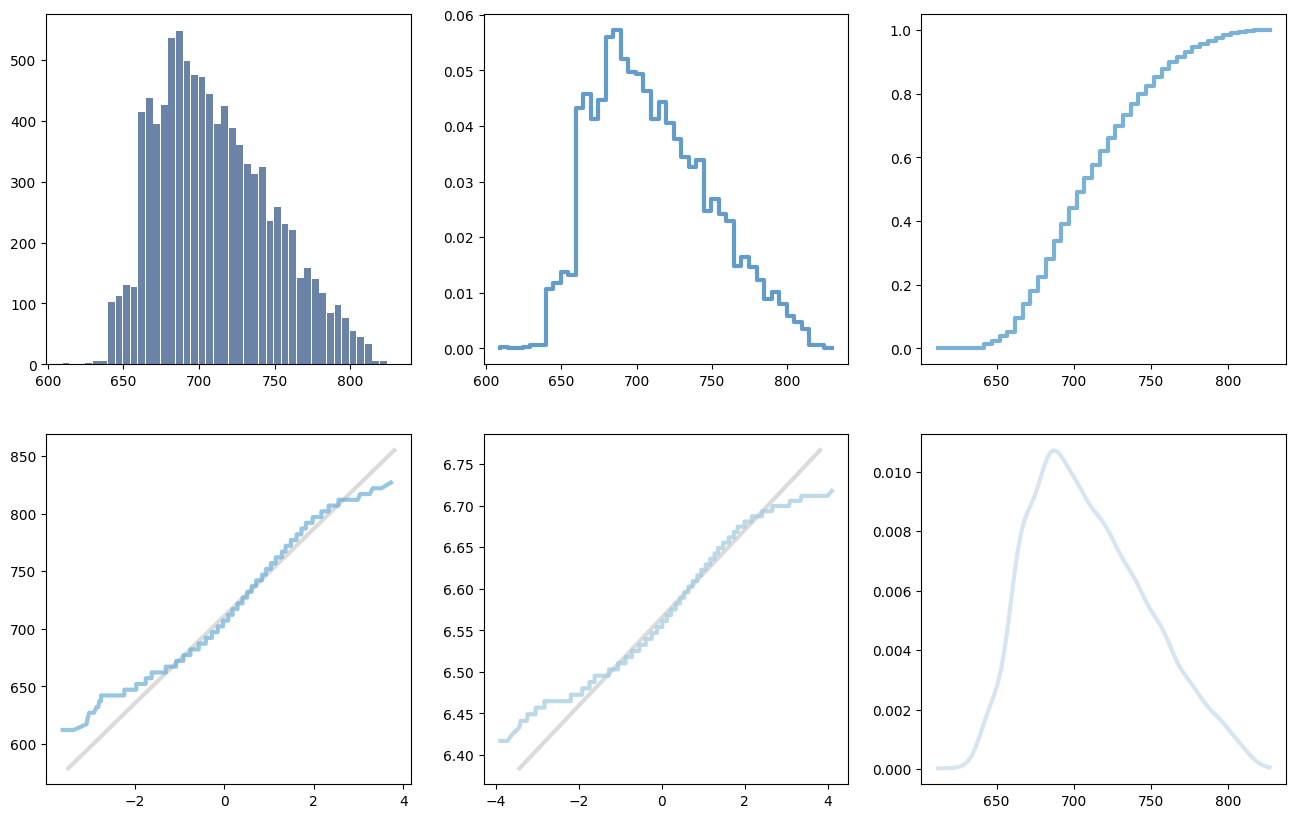

In [6]:
#Create graphs
thinkplot.PrePlot(6, rows =2, cols=3)
thinkplot.Hist(hist2)
thinkplot.SubPlot(2)
thinkplot.Pmf(pmf2)
thinkplot.SubPlot(3)
thinkplot.Cdf(cdf2)
thinkplot.SubPlot(4)
thinkstats2.NormalProbabilityPlot(df["fico"])
thinkplot.SubPlot(5)
thinkstats2.NormalProbabilityPlot(np.log(df["fico"]))
thinkplot.SubPlot(6)
pdf = thinkstats2.EstimatedPdf(df["fico"]) #See more below
thinkplot.Pdf(pdf)
thinkplot.Config()

#### Multiple Plots on a Grid

In the examples both above and below we have a grid of multiple graphs. Each one is done in a different way. 

In the thinkplot stuff we have a helper called PrePlot, which we can use to define the size of the grid, along with the subPlot function that can basically "aim" the next chart into the desired slot. 

In the seaborn stuff below, we have a grid using pyplot subplots. Here we define a set of sublots, then in each individual plot we assign it a slot. 

Both of these are built upon the foundations of pyplot (which is part of matplotlib), so there is often, but not always interoperability. The method below is farily generic and will work in many places, with many graphs. Note that (for reasons we really don't care about, it has to do with if the function only provides an "image" of a graph, or an entire "object" of a graph) there are some scenarios that making a grid like this won't work. The easiest way to confirm is to Google, "seaborn [graphtype] subplots" and there will be several examples (usually stackoverflow ones have good explained examples) that can normally be easily adapted. There are a bunch of ways to do this, and a bunch of semi-related garphing libraries and types of graphs, so there isn't a "one true answer". 

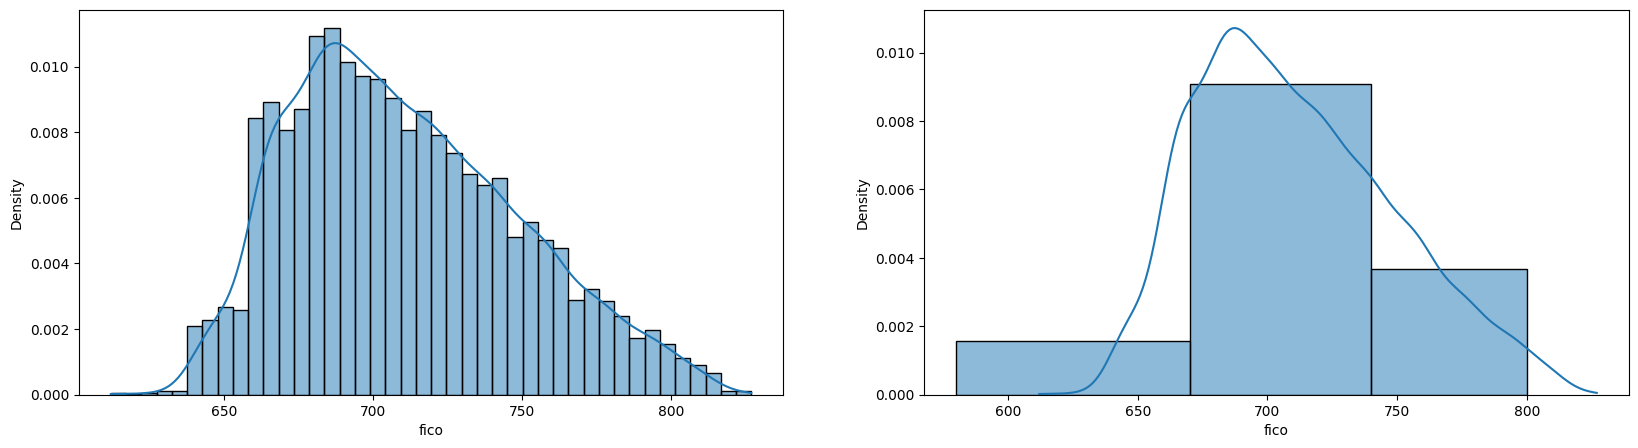

In [7]:
#We can use seaborn as well

plt.rcParams["figure.figsize"] = (20,5) #makes the default size larger. 
#Everything after the comma is optional. 
fig, ax = plt.subplots(1,2)
sns.histplot(df["fico"], kde=True, stat="density", ax=ax[0])
sns.histplot(df["fico"], bins=bins, kde=True, stat="density", ax=ax[1])
plt.show()

### KDE and Histogram

As above - the KDE produces a smoothed function, and approximates the distribution of the histogram. Especially when the volume of data becomes large, a KDE may be a more useful visualization of a distribution. 

The smaller those bins get, the closer of an approximation. The smoothing factor accounts for 'noise' - e.g. around 750ish. On the whole, this delivers a distribution shape that isn't impacted directly by sharp ups and downs at certain points on the distribution, like a histogram is. For generalizing from a sample to a population, this is useful...


## Kernel Density Estimation (KDE)

We can look at a simple example of how KDE works with this example function. The function takes a set of data, and for each data point, it places a small "kernel" (a mini gaussian bump) on top of that data point. The final KDE curve is the average of all these individual kernels.

The process going on in the function is as follows:

1. For each data point, we create a small Gaussian distribution centered at that point. The width of this Gaussian is determined by the bandwidth parameter. A smaller bandwidth results in a narrower peak, while a larger bandwidth results in a wider peak.
2. We evaluate the Gaussian distribution at a set of points (grid) that span the range of the data. This gives us the height of the Gaussian at each point in the grid.
3. We sum up the contributions from all the individual Gaussians to get the overall density estimate at each point in the grid.
4. Finally, we normalize the density estimate so that the area under the curve sums to 1, making it a valid probability density function.

The visualizations show some example, interim, 'blendings'. Each of those charts show what the PDF curve looks like after incorporating N data points, selected at random, from the generated data. As the number of data points increases, the KDE curve becomes a better approximation of the true underlying distribution.

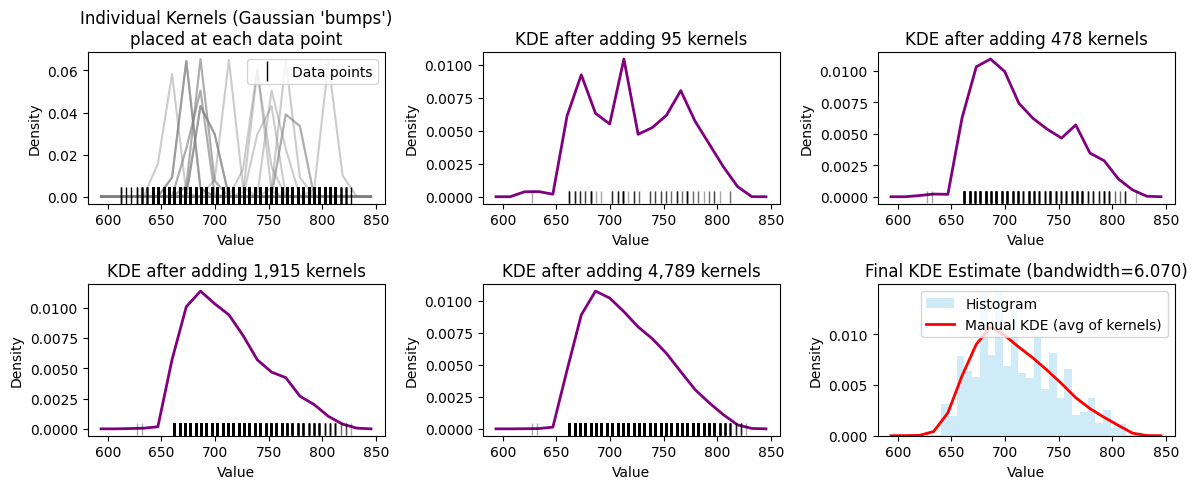

In [8]:
# Example of KDE calculations
def manual_kde_demo(data, bandwidth=None, num_points=20):
    """
    Illustrates how Kernel Density Estimation (KDE) works by manually
    placing a small "kernel" (a mini gaussian bump) on top of each data
    point, then summing them all up to get a smooth density curve.
    """
    data = np.asarray(data)
    n = len(data)

    # If no bandwidth given, use Scott's rule of thumb 
    if bandwidth is None:
        bandwidth = n ** (-1 / 5) * data.std(ddof=1)

    # Create a range of x-values spanning a bit wider than our data, this is where we will evaluate the KDE
    x_grid = np.linspace(data.min() - 3 * bandwidth, data.max() + 3 * bandwidth, num_points)

    # This will hold the individual little "kernel" curves - one per data point
    individual_kernels = np.zeros((n, num_points))

    # Place a Gaussian kernel (bell curve) centered at each data point
    for i, point in enumerate(data):
        # Each kernel is just a normal distribution centered on that specific data point
        individual_kernels[i, :] = scipy.stats.norm.pdf(x_grid, loc=point, scale=bandwidth)
        #print(f"Kernel for data point {point:.2f} placed on x_grid:\n{individual_kernels[i, :]}")

    # The final KDE curve is the average of all these individual kernels
    kde_curve = individual_kernels.mean(axis=0)

    # ---- Plot 1: show a handful of the individual kernels being summed ----
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    # Only plot a sample of kernels so the graph isn't too cluttered
    sample_idx = np.random.choice(n, size=min(20, n), replace=False)
    for i in sample_idx:
        plt.plot(x_grid, individual_kernels[i, :], color="gray", alpha=0.4)
    # Overlay the actual data points on the x-axis
    plt.plot(data, np.zeros_like(data), "|", color="black", markersize=15, label="Data points")
    plt.title("Individual Kernels (Gaussian 'bumps')\nplaced at each data point")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    # Expand the figure to a 2x3 grid and retain the first chart
    figure = plt.gcf()
    grid = figure.add_gridspec(2, 3)
    plt.gca().set_subplotspec(grid[0, 0])

    # Show progressively larger sets of kernels being averaged together
    cumulative_kernels = np.cumsum(individual_kernels, axis=0)
    steps = np.unique(np.maximum(1, (n * np.array([0.01, 0.05, 0.20, 0.50])).astype(int)))

    for position, count in zip([2, 3, 4, 5], steps):
        ax = figure.add_subplot(grid[(position - 1) // 3, (position - 1) % 3])
        interim_kde = cumulative_kernels[count - 1] / count

        ax.plot(x_grid, interim_kde, color="purple", linewidth=2)
        ax.plot(
            data[:count],
            np.zeros(count),
            "|",
            color="black",
            alpha=0.35,
            markersize=8,
        )
        ax.set_title(f"KDE after adding {count:,} kernels")
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")

    # Redirect the existing final plot below into the sixth grid position
    original_subplot = plt.subplot

    def kde_subplot(*args, **kwargs):
        if args[:3] == (1, 2, 2):
            plt.subplot = original_subplot
            final_ax = figure.add_subplot(grid[1, 2])
            plt.sca(final_ax)
            return final_ax
        return original_subplot(*args, **kwargs)

    plt.subplot = kde_subplot
    # ---- Plot 2: show the final summed/averaged KDE curve vs a histogram ----
    plt.subplot(1, 2, 2)
    plt.hist(data, bins=30, density=True, alpha=0.4, label="Histogram", color="skyblue")
    plt.plot(x_grid, kde_curve, color="red", linewidth=2, label="Manual KDE (avg of kernels)")
    plt.title(f"Final KDE Estimate (bandwidth={bandwidth:.3f})")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Return the grid and curve in case we want to inspect/use the model numerically
    return x_grid, kde_curve


# Run the demo on the fico score data we already have loaded
grid1, curve1 = manual_kde_demo(df["fico"])

Now we can try it with a small sample of data, so the KDE process is more 'stressed'. 

<Axes: xlabel='fico', ylabel='Density'>

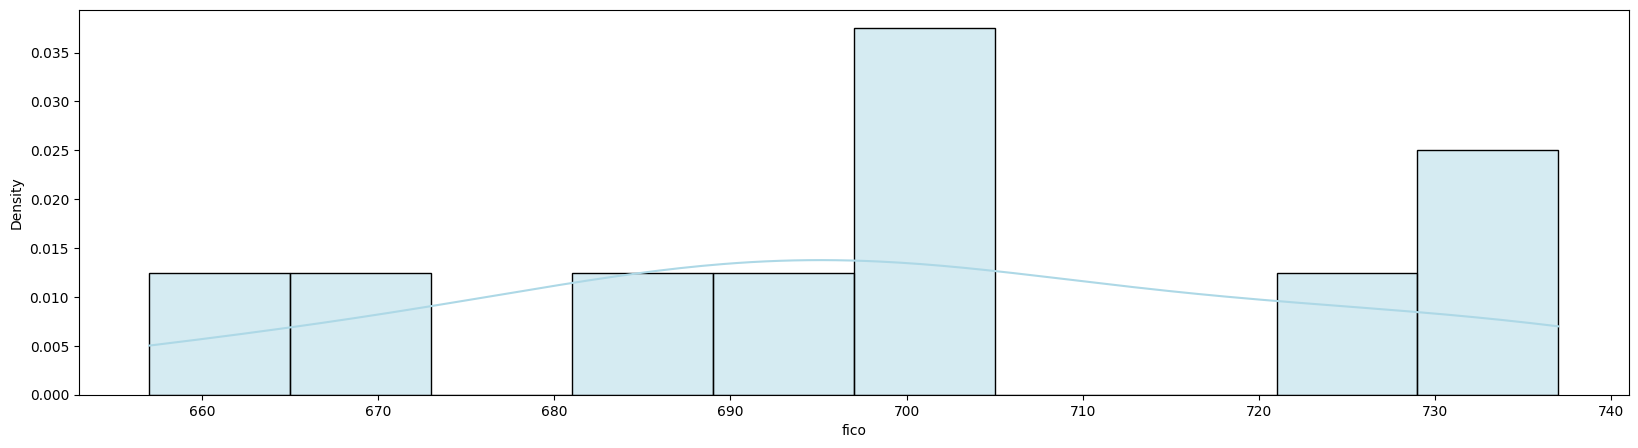

In [9]:
fico_subset = df["fico"].sample(n=10, random_state=42)
sns.histplot(fico_subset, bins=10, kde=True, stat="density", color="lightblue", label="Histogram")

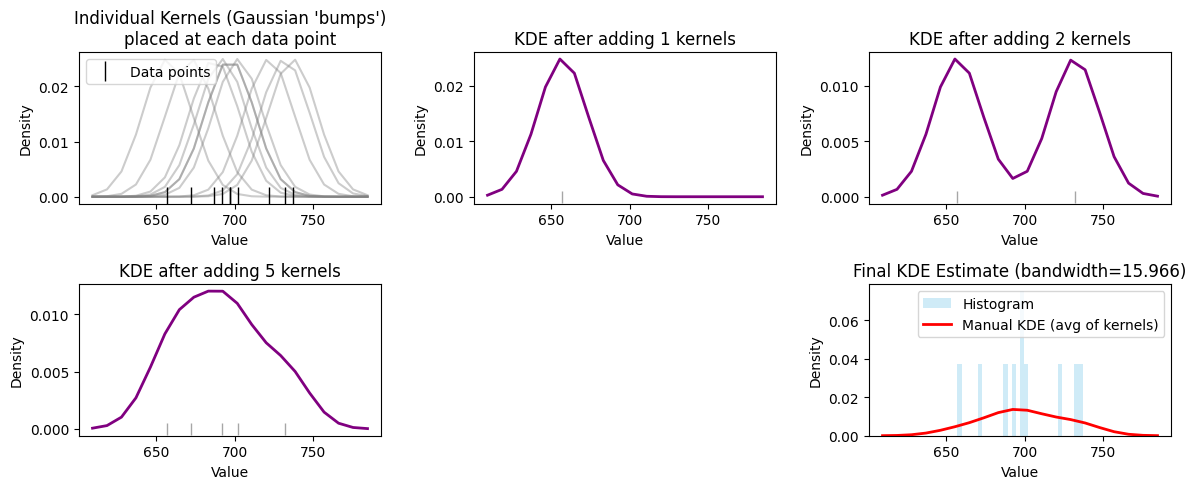

In [10]:
grid2, curve2 = manual_kde_demo(fico_subset)

#### Bandwidths

The bandwidth parameter controls the smoothness of the KDE curve, more specifically, it controls the standard deviation of the Gaussian kernels used in the estimation. A smaller bandwidth results in a more sensitive KDE that captures more details of the data, while a larger bandwidth produces a smoother curve that may overlook finer details.

The default value of the bandwidth is often determined by an equation called Scott's Rule, which produces a bandwidth that is proportional to the standard deviation of the data and inversely proportional to the cube root of the number of data points. This is a good starting point, but may not be perfect for all scenarios. 

Bandwidth: 0.1


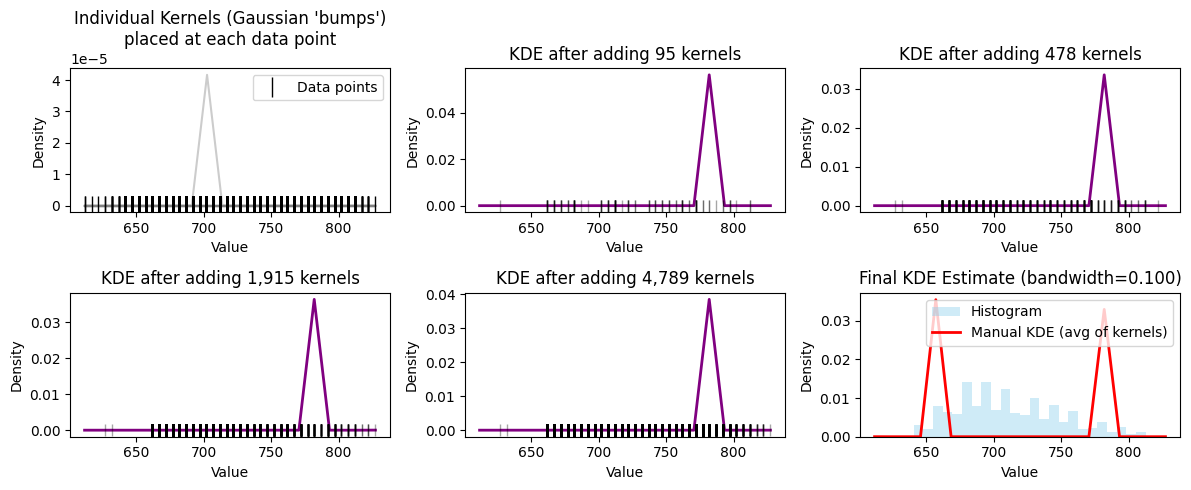

Bandwidth: 0.5


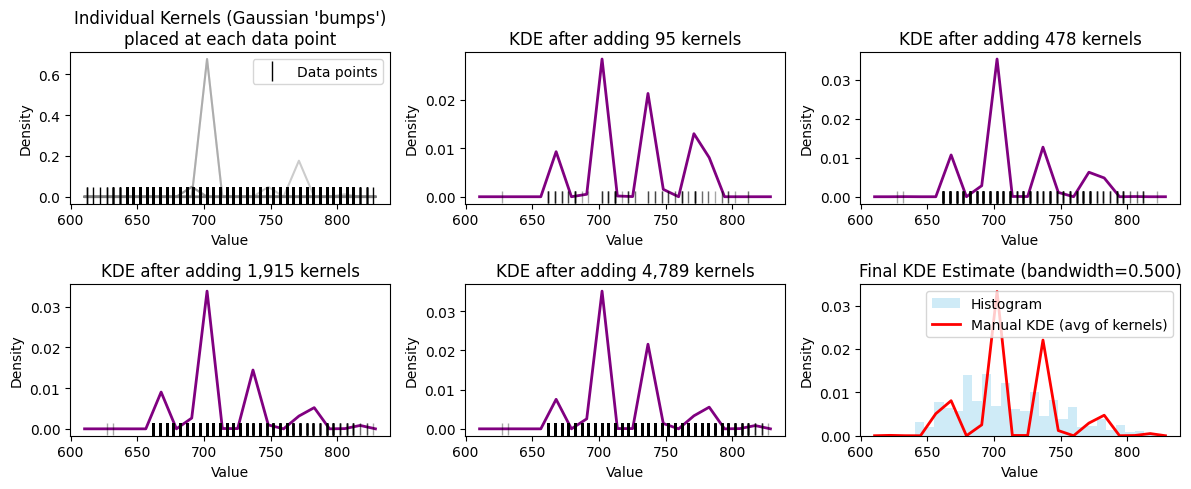

Bandwidth: 1


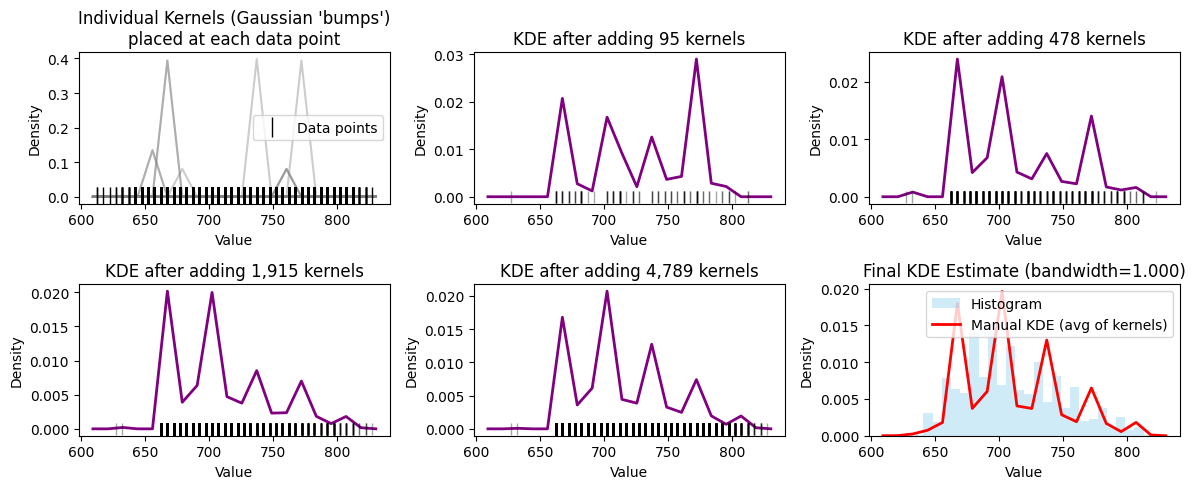

Bandwidth: 2


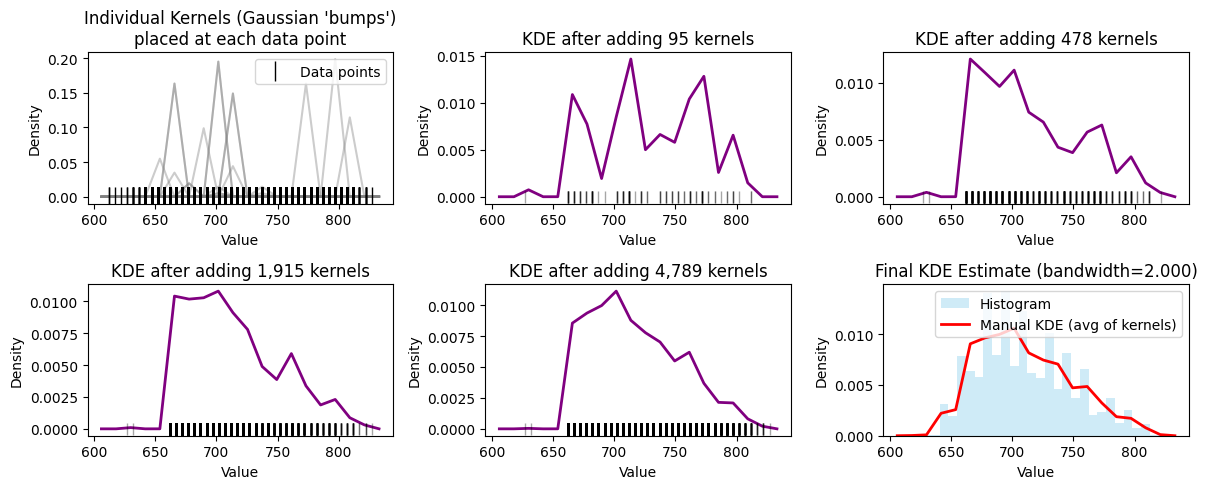

Bandwidth: 10


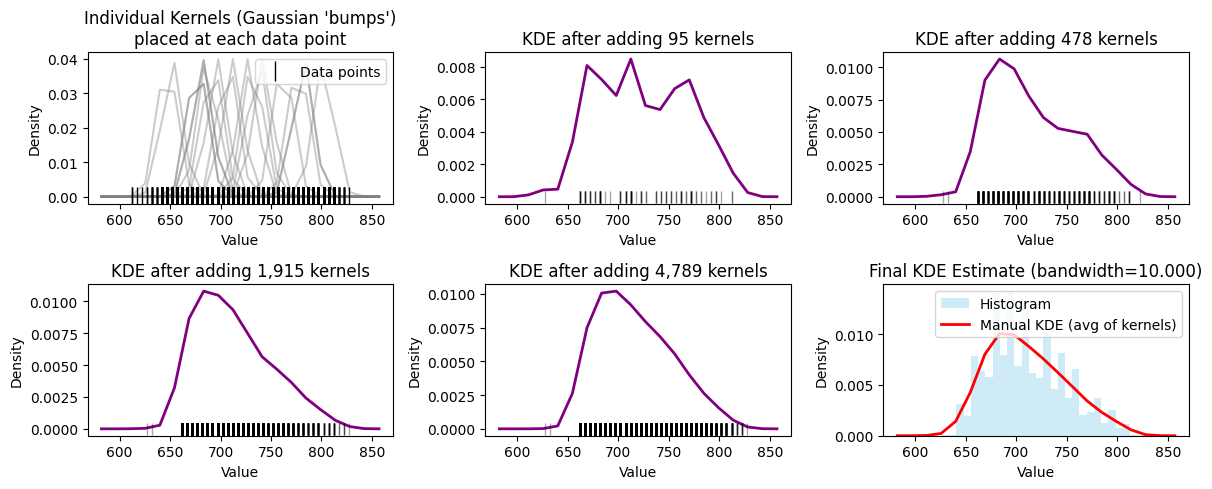

Bandwidth: 1000


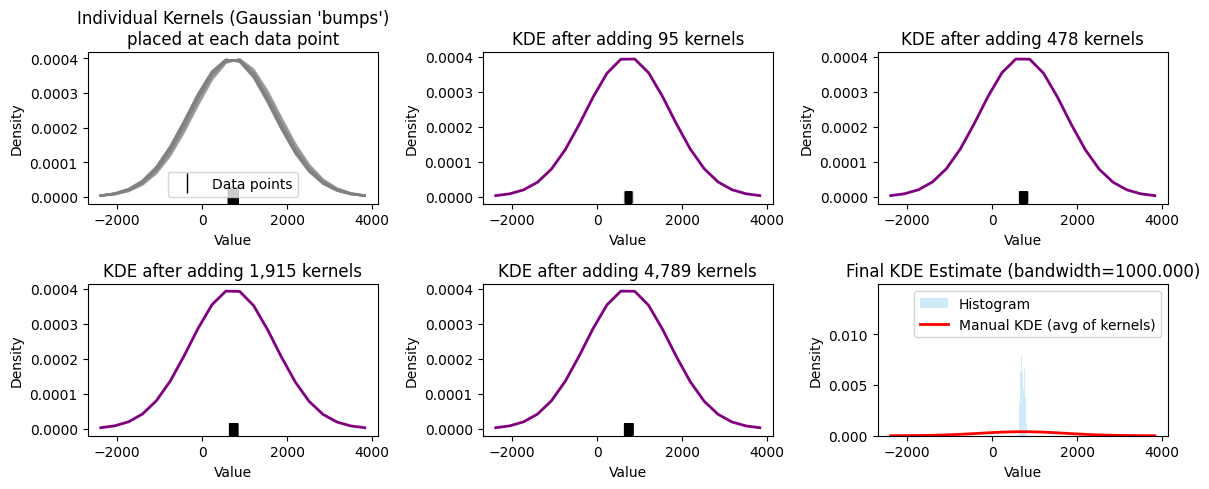

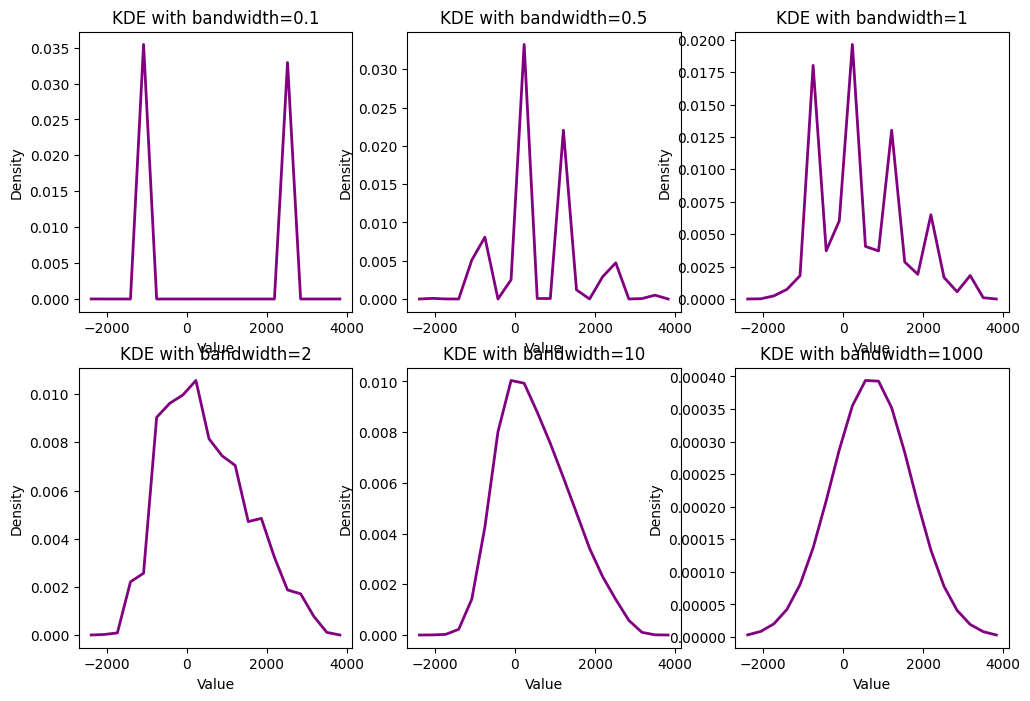

In [ ]:
bandwidths = [0.1, .5, 1, 2, 5, 10]
curves = []
for bandw in bandwidths:
    print(f"Bandwidth: {bandw}")
    grid, curve = manual_kde_demo(df["fico"], bandwidth=bandw)
    curves.append(curve)

fig, ax = plt.subplots( 2,3, figsize=(12, 8))
for i, curve in enumerate(curves):
    ax.flat[i].plot(grid, curve, color="purple", linewidth=2)
    ax.flat[i].set_title(f"KDE with bandwidth={bandwidths[i]}")
    ax.flat[i].set_xlabel("Value")
    ax.flat[i].set_ylabel("Density")

### Skewness

![Skew](images/skew.png)

Skewness. We can visually see the skew - this one is right skewed a bit - the right side is "stretched" out a bit more. Skew is both easy to see and easy to calculate, we also have a quick rule of thumb that we can figure out with basic satistics:
<ul>
<li>If the mean is greater than the median, the distribution is positively skewed.
<li>If the mean is less than the median, the distribution is negatively skewed.
</ul>

The value of the skew can be calculated with a function called Pearson Median Skewness, which is defined as:

$$ Skew = \frac{3(X_i - \mu)}{\sigma} $$

The values for skew don't have any specific meaning, the larger magnitude it is, the larger the skew. As a rule of thumb, values greater than 1 are highly skewed. 

We can verify with caclculations...

In [12]:
#Skew
skw = thinkstats2.PearsonMedianSkewness(df["fico"])
print(df["fico"].mean())
print(df["fico"].median())
print(skw)

710.8463144706619
707.0
0.3039078893542743


We can show it a little more clearly on the graph by adding some reference lines for mean and median. We can see that the mean is now greater than the median. 

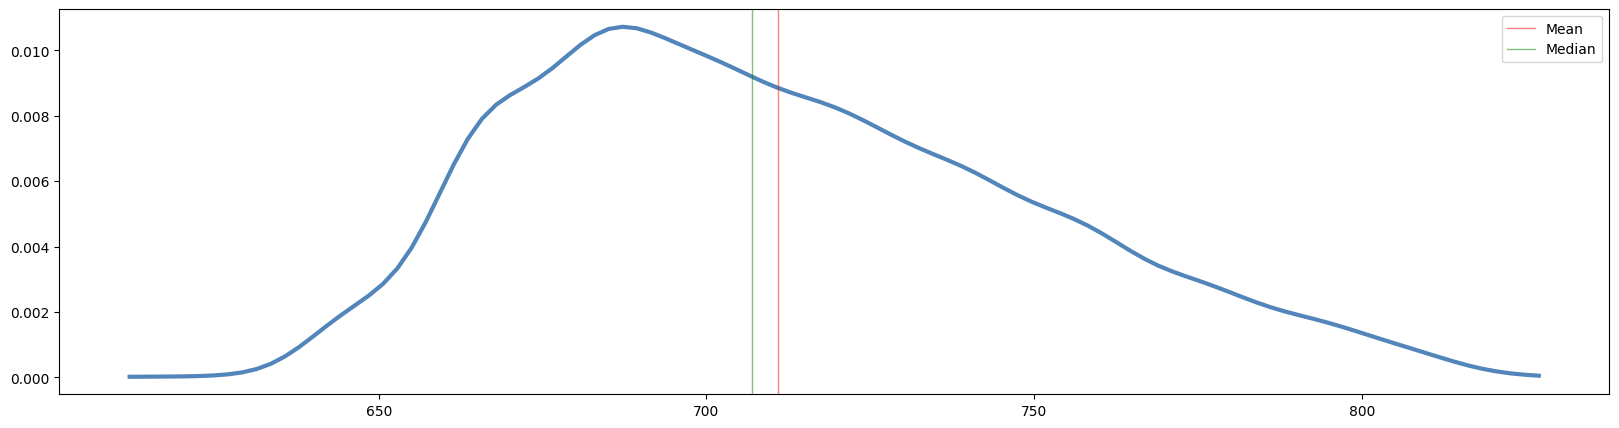

In [13]:
thinkplot.PrePlot(1)
thinkplot.Pdf(pdf)
thinkplot.axvline(df["fico"].mean(), color="Red", label="Mean")
thinkplot.axvline(df["fico"].median(), color="Green", label="Median")
thinkplot.Config()

### Fit a Distribution

We can also fit a distribution to the data and get back the parameters of that distribution. This isn't theoretically different from calculating the parameters directly, but it does offer a few advantages at times:
<ul>
<li> We can fit a distribution and get all parameters at once, instead of calculating them one at a time.</li>
<li> For some things, like the exponential distribution, the real parameters are not as straightforward to calculate.</li>
</ul>

Be attentive to the order of the parameters returned, and what they mean - consulting the documentation is always a good idea.

(np.float64(710.8463144706619), np.float64(37.968555000342505))


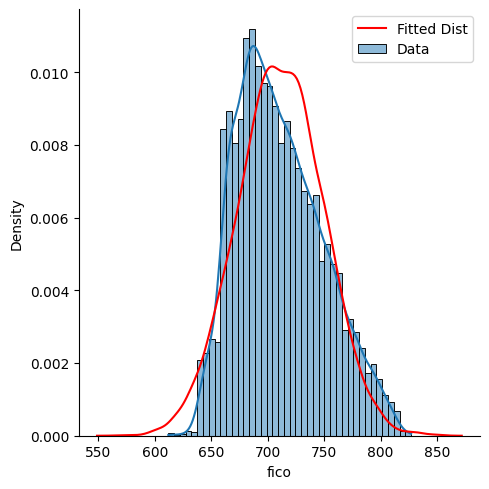

In [14]:
# Fit a distribution and print sample
fico_params = scipy.stats.norm.fit(df["fico"])
print(fico_params)
fico_dist = scipy.stats.norm(fico_params[0], fico_params[1])
sns.displot(df["fico"], kde=True, stat="density", label="Data")
sns.kdeplot(data=fico_dist.rvs(10000), color="red", label="Fitted Dist")
plt.legend()
plt.show()


#### Exponential Distribution

The exponential distribution is a bit different, it is defined by a single parameter, lambda. This is the rate parameter, and is the inverse of the mean.

$ \lambda = \frac{1}{\mu} $

In practice, we need to use the loc and scale parameters to get the distribution to fit properly. The loc is the minimum value, and the scale is the inverse of lambda (the mean). There's a bit of an explanation on the scipy documentation page, but the short version is that the exponential distribution is defined on the interval [0, inf), so if your data has a minimum value greater than 0, you need to set the loc parameter to that minimum value.

<Axes: ylabel='Density'>

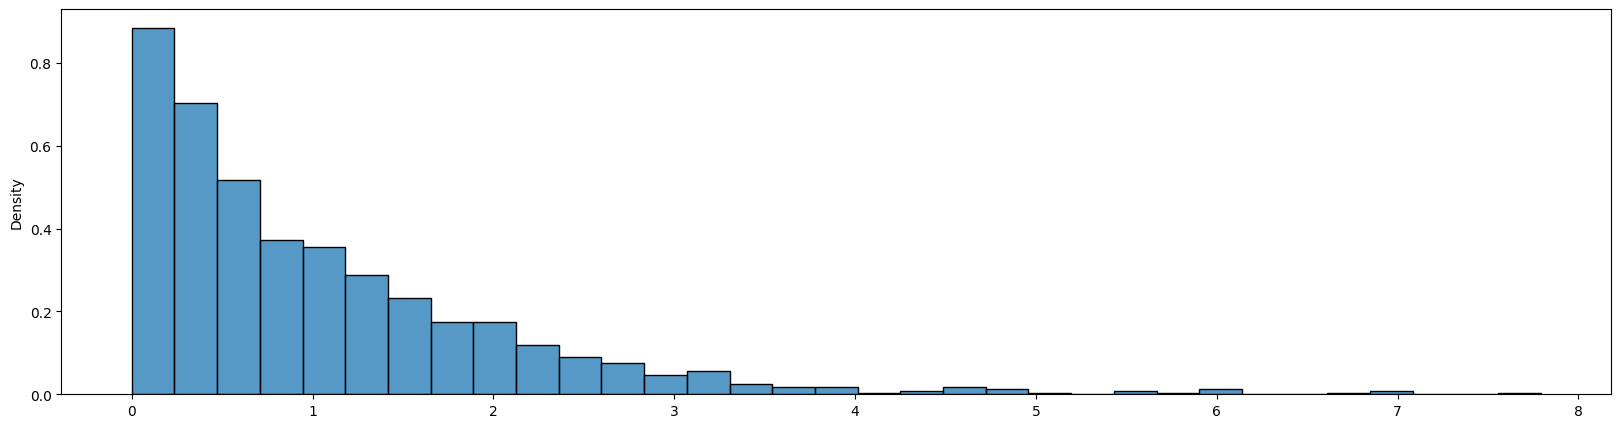

In [15]:
# Sample exponential distribution data
exp_data = np.random.exponential(scale=1.0, size=1000)
sns.histplot(exp_data, label="Data", kde=False, stat="density")

##### Get the Parameters

The fit function returns the parameters of the distribution. For a normal distribution, this is the mean and standard deviation, for other distributions it may be different. The first parameter is usually the location (mean), the second is usually the scale (standard deviation), but check the documentation for the specific distribution to be sure.

Location: 0.0001907700044954974
Scale: 1.0462993611004683


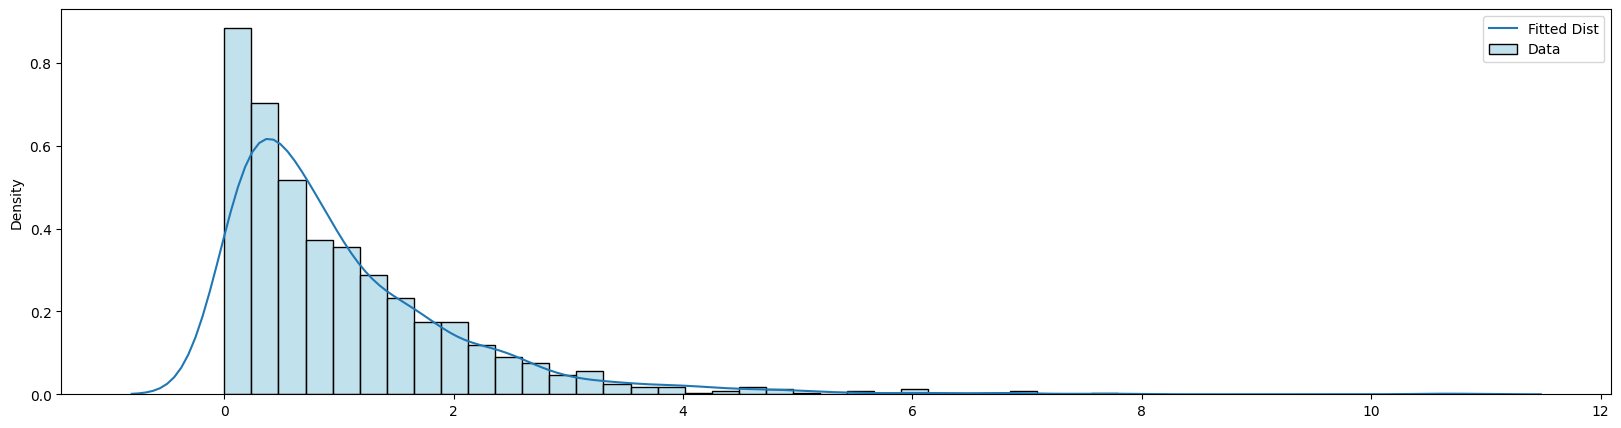

In [16]:
exp_params = scipy.stats.expon.fit(exp_data)
#print each parameter
print("Location:", exp_params[0])
print("Scale:", exp_params[1])
exp_dist = scipy.stats.expon(exp_params[0], exp_params[1])
sns.kdeplot(data=exp_dist.rvs(1000), label="Fitted Dist", fill=False)
sns.histplot(exp_data, label="Data",stat="density", kde=False, color="lightblue")
plt.legend()

## Small Exercise - Fit Beta Distribution

Here's some data that follows a beta distribution. Fit a beta distribution to the data, and plot the results. If you have time, try to fit some other distributions and see how they compare. 

<a href="https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html"> Scipy Beta Distribution Documentation</a>

<Axes: ylabel='Density'>

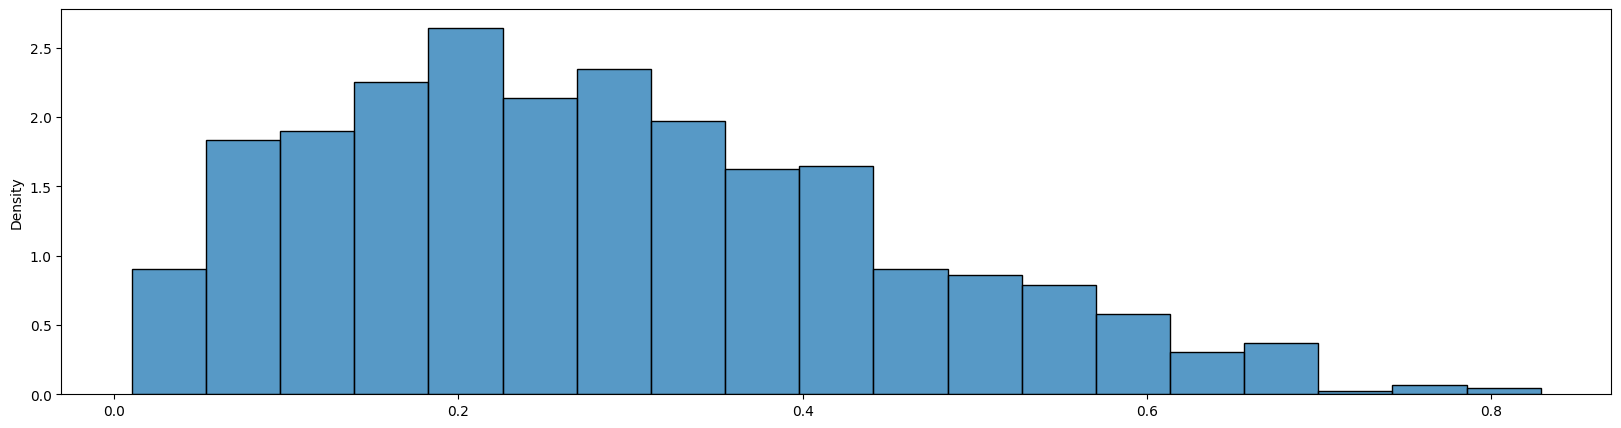

In [17]:
# Generate beta distribution data
beta_data = np.random.beta(a=2.0, b=5.0, size=1000)
sns.histplot(beta_data, label="Data", kde=False, stat="density")

(np.float64(1.801458713276445), np.float64(4.02581253525338), np.float64(0.004813376273539683), np.float64(0.9085623248139277))


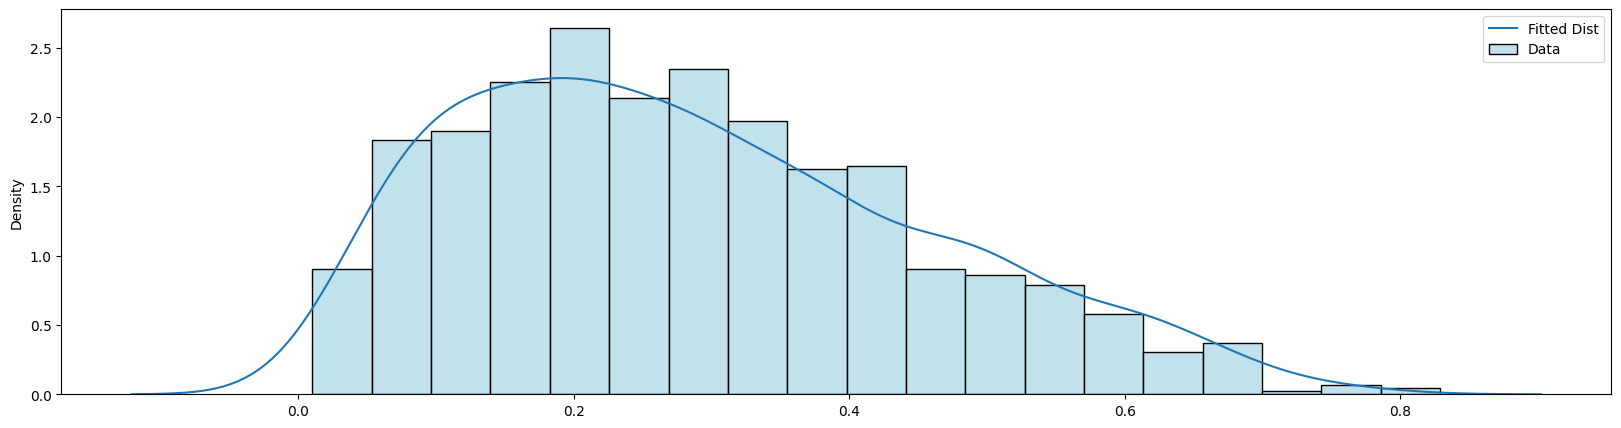

In [18]:
# Fit distribution
beta_params = scipy.stats.beta.fit(beta_data)
print(beta_params)
beta_dist = scipy.stats.beta(beta_params[0], beta_params[1], beta_params[2], beta_params[3])
sns.kdeplot(data=beta_dist.rvs(1000), label="Fitted Dist", fill=False)
sns.histplot(beta_data, label="Data", kde=False, stat="density", color="lightblue")
plt.legend()
plt.show()

## Income

We can explore a different varaible similarly - income. 

We are given the income in log format. Why might that be? Can you investigate a little, and add normal income to the dataframe?

In [19]:
#create a new column - income. This should show the regular income, not log transformed. 
df["income"] = np.exp(df["log.annual.inc"])
df["income"].describe()

count    9.578000e+03
mean     6.840203e+04
std      6.122753e+04
min      1.896000e+03
25%      3.850000e+04
50%      5.576400e+04
75%      8.012100e+04
max      2.039784e+06
Name: income, dtype: float64

### Exercise #1 - Create a Function

Try to make a function that prints all the 6 graphs we made above when provided with data. 

In [20]:
# Challenge - try to create a function that makes the suite of 6 graphs above.
def bigGraph(df_in, columnName):
    data = pd.Series(df_in[columnName])
    hist = thinkstats2.Hist(data)
    pmf = thinkstats2.Pmf(data)
    cdf = thinkstats2.Cdf(data)
    pdf = thinkstats2.EstimatedPdf(data) #See more below

    thinkplot.PrePlot(6, rows =2, cols=3)
    thinkplot.SubPlot(1, title="Hist")
    thinkplot.Hist(hist)
    thinkplot.SubPlot(2, title="PMF")
    thinkplot.Pmf(pmf)
    thinkplot.SubPlot(3, title="CDF")
    thinkplot.Cdf(cdf)
    thinkplot.SubPlot(4, title="Prob Plot")
    thinkstats2.NormalProbabilityPlot(data)
    thinkplot.SubPlot(5, title="Log PP")
    thinkstats2.NormalProbabilityPlot(np.log(data))
    thinkplot.SubPlot(6, title="PDF")
    thinkplot.Pdf(pdf)
    
    thinkplot.Config()
    return

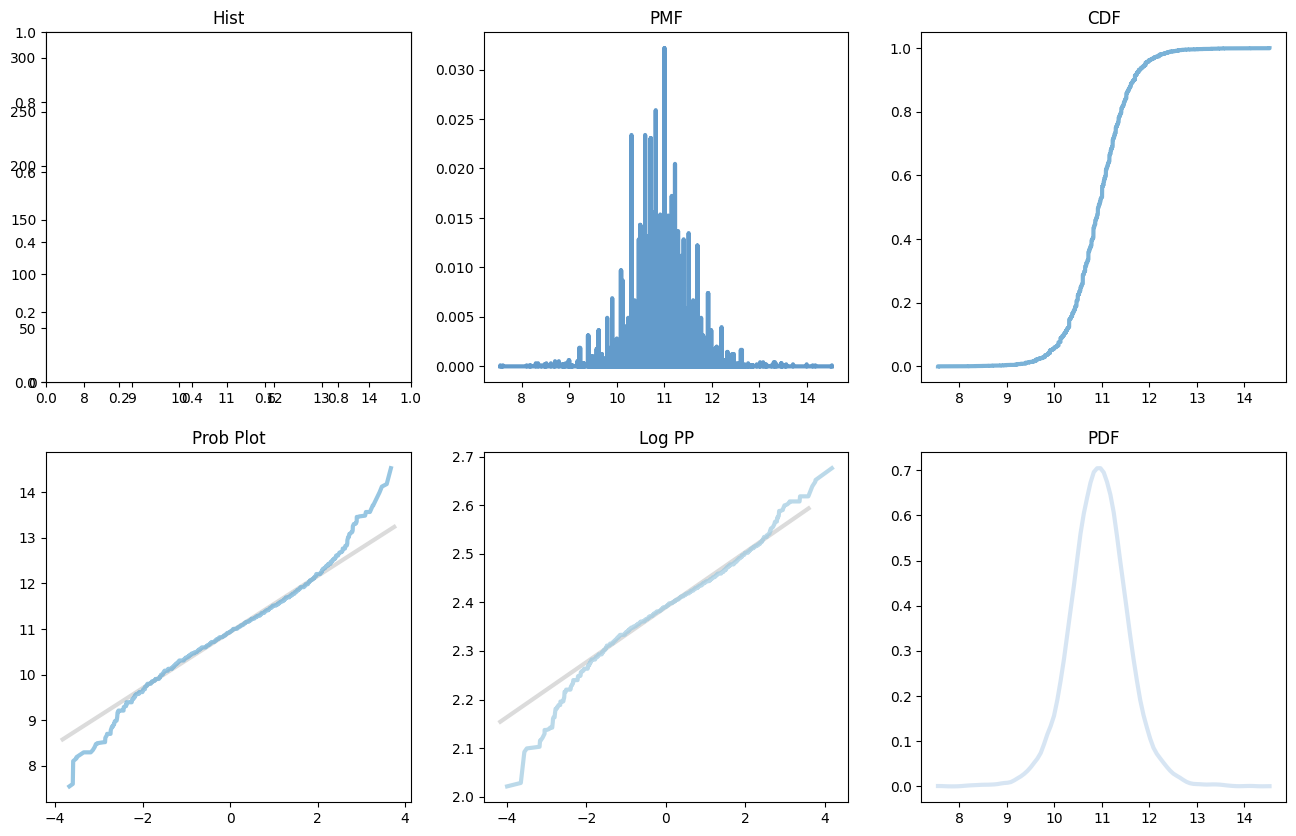

In [21]:
# Draw graphs
bigGraph(df, "log.annual.inc")

### Exercise #2: Establish Tax Rates

Try to use the data - break into groups of marginal tax rates:
<ul>
<li>15% on the first $49,020 of taxable income, plus
<li>20.5% on the next $49,020 of taxable income (on the portion of taxable income over 49,020 up to $98,040), plus
<li>26% on the next $53,939 of taxable income (on the portion of taxable income over $98,040 up to $151,978), plus
<li>29% on the next $64,533 of taxable income (on the portion of taxable income over 151,978 up to $216,511), plus
<li>33% of taxable income over $216,511
</ul>

<b>Generate bins for each tax bracket</b>

In [22]:
# Generate bins for each tax bracket
incBins = [49020, 98040, 151978, 216511]
ind = np.digitize(df["income"], incBins)
incGroups = df.groupby(ind)

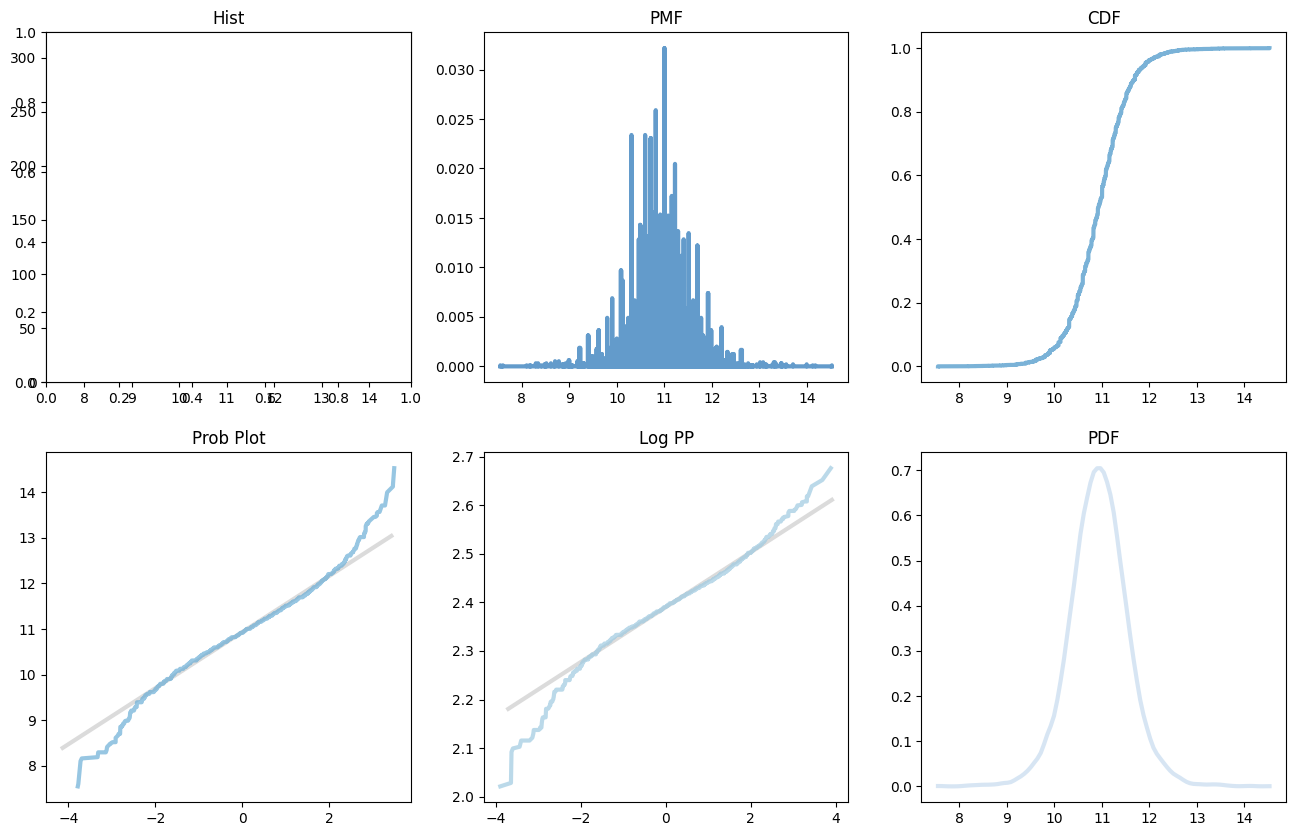

In [23]:
#Create the 6 graph set of graphs for original log income
bigGraph(df, "log.annual.inc")

<b>Use the data to estimate the number of people in each tax bracket</b>

Try to look through the bins, if you can. See the solution for a hint, if needed. 

In [24]:
for i, group in incGroups:
    print(i, len(group), group["income"].mean())

0 3842 33676.13357878794
1 4206 68377.60314278335
2 1096 118291.30739083122
3 261 179094.59077441727
4 173 357131.70532451425


<b>Use the cdf to estimate the number of people who earn Teacher Money - lowest: 59,357, highest: 101,162</b>

In [25]:
cdfInc = thinkstats2.Cdf(df["income"])
teachLow = 59357
teachHigh = 101162
cdfInc.Prob(teachLow), cdfInc.Prob(teachHigh)

(np.float64(0.531008561286281), np.float64(0.8592608060137816))

<b>Create a KDE showing the distributiion of income. Try both log income, and raw income. </b>

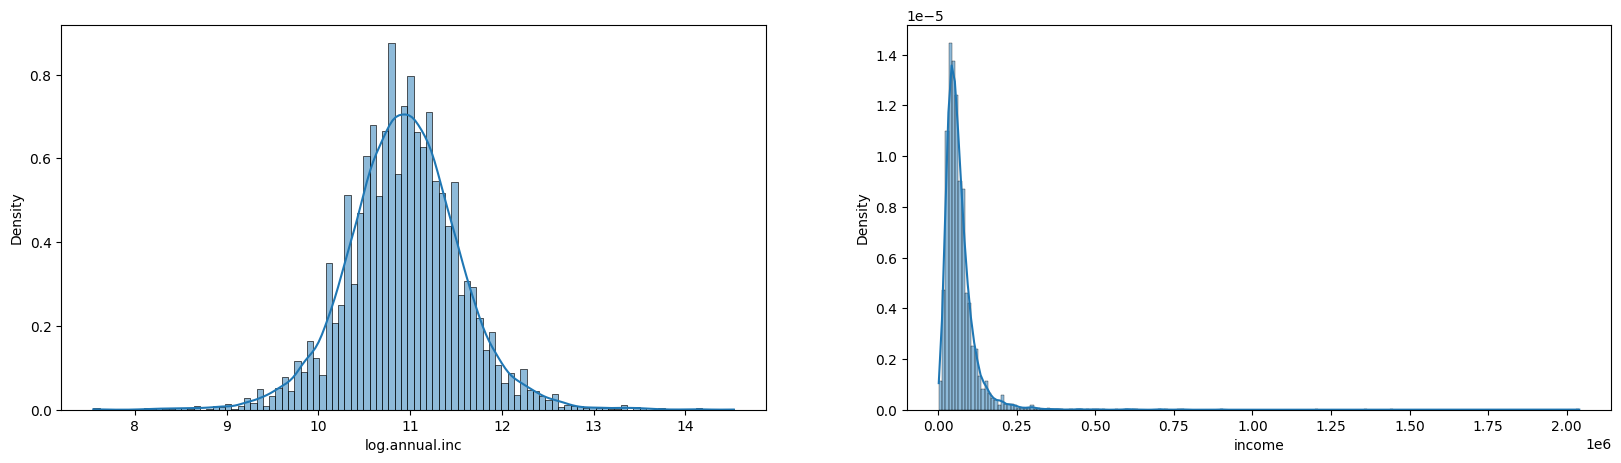

In [26]:
fig, ax = plt.subplots(1,2)
sns.histplot(df["log.annual.inc"], kde=True, stat="density", ax=ax[0])
sns.histplot(df["income"], kde=True, stat="density", ax=ax[1])
plt.show()

#### Do the Same, with Analytical Distributions

Fit parameters: shape= 0.004824808708646861 , scale= 127.41632717718751 , loc= -116.48569310704524


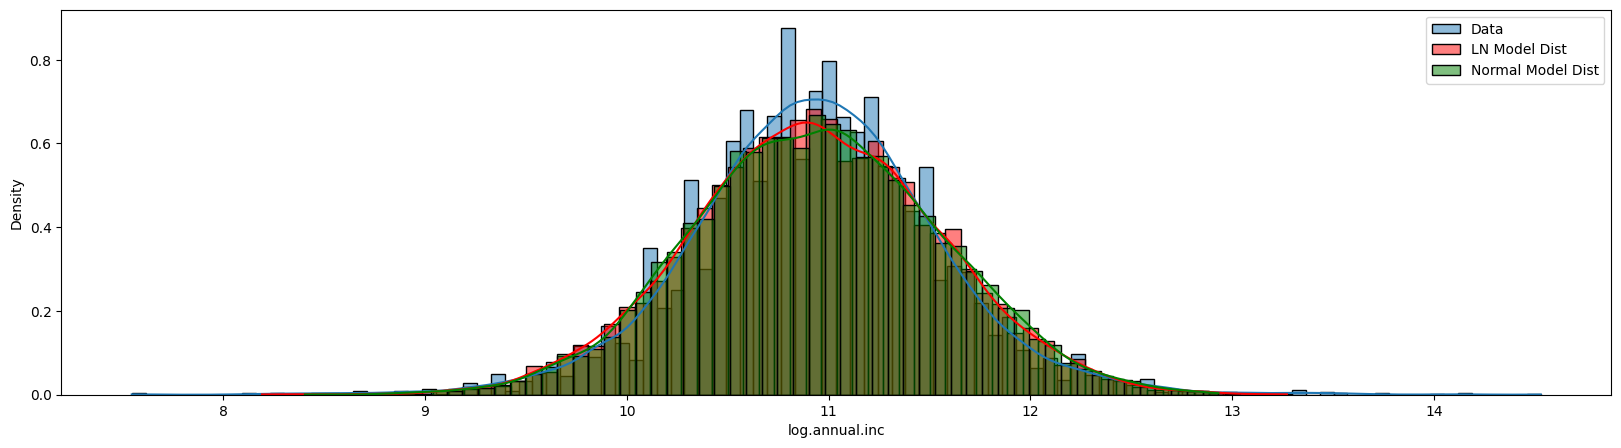

In [27]:
lnFit = scipy.stats.lognorm.fit(df["log.annual.inc"])
lnFitModel = scipy.stats.lognorm(lnFit[0], lnFit[1], lnFit[2])
lnFitSample = lnFitModel.rvs(size=len(df))
print("Fit parameters: shape=", lnFit[0], ", scale=", lnFit[2], ", loc=", lnFit[1])
sns.histplot(df["log.annual.inc"], kde=True, stat="density", label="Data")
sns.histplot(lnFitSample, kde=True, stat="density", label="LN Model Dist", color="red")

normFrozen = scipy.stats.norm(loc=df["log.annual.inc"].mean(), scale=df["log.annual.inc"].std())
normFitSample = normFrozen.rvs(size=len(df))
sns.histplot(normFitSample, kde=True, stat="density", label="Normal Model Dist", color="green")

plt.legend()

##### Teacher Income 

In [28]:
upperCut = lnFitModel.cdf(teachHigh)
lowerCut = lnFitModel.cdf(teachLow)
percentInRange = upperCut - lowerCut
print(f"Percentage of teachers with income between ${teachLow} and ${teachHigh}: {percentInRange:.2%}")
print("Crap, we suck!")
logUpperCut = lnFitModel.cdf(np.log(teachHigh))
logLowerCut = lnFitModel.cdf(np.log(teachLow))
logPercentInRange = logUpperCut - logLowerCut
print(f"Percentage of teachers with income between ${teachLow} and ${teachHigh} (log transformed): {logPercentInRange:.2%}")

Percentage of teachers with income between $59357 and $101162: 0.00%
Crap, we suck!
Percentage of teachers with income between $59357 and $101162 (log transformed): 29.31%


## Exercise #2: Tax Function

Try this! 

In [29]:
#Challenge - Create a function that takes an income and returns a tax bill, effective rate, and marginal tax rate:
def muhTaxes(income):
    pass
    #return taxbill, effectiveRate,margRate

In [30]:
# When calling that function, you can do something like this to get the results:
# tax_bill, effective_rate, marginal_rate = muhTaxes(amount_i_earned)
# print("Tax bill: ", tax_bill)
# print("Effective rate:", effective_rate)
# print("Marginal rate:", marginal_rate)

### Use It

<ul>
  <li>What is the average tax rate for the "middle class" - use the middle two quartiles of income.</li>
  <li>What is the median effective tax rate for the top 10% vs the bottom 10% of income.</li>
</ul>

In [31]:
# Try

## So... Why a Log?

Think quickly - we have both the log and non-log data (there's just a math operation that differs between them, so we can always translate - or transform - back and forth), why bother with the log? 

We are ultimately concerned with using our data to draw inference, which means we are introducing some assumptions. Suppose we want to use the data to estimate the distance between the lowest and highest quintiles of income. If we only care about the sample's data, we can just count, no transformation needed. If we are attempting to generalize from our sample to the population (as we will soon), using the normal distribution allows us to use all of the things that are built to deal with normal distributions - in this case slicing segments of the data. Similarly, when we want to do tests to measure things about our data (such as hypothesis tests), many of those tests are created for normal data specifically. 

In general, we want to make data "as easy as possible to analyze", and making data normal (or sometimes transforming it in different ways, like normalization), often makes it easier. So we do it. 